# Project Goal

The objective of this machine learning project is to predict a student's overall academic performance (Average Score) based strictly on their demographic and socioeconomic background features. It models how external factors influence educational outcomes.

# Task 8: Machine Learning Model (Student Performance Dataset)

# Import Dataset Libraries

In [5]:
# 1. पहले सारे Libraries इम्पोर्ट करें
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Data Load 

In [6]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# Basic Information

In [7]:
df.shape

(1000, 8)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [10]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# Check Missing Values

In [11]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

# Duplicate Records

In [13]:
df.duplicated().sum()

np.int64(0)

# EDA

Gender Distribution


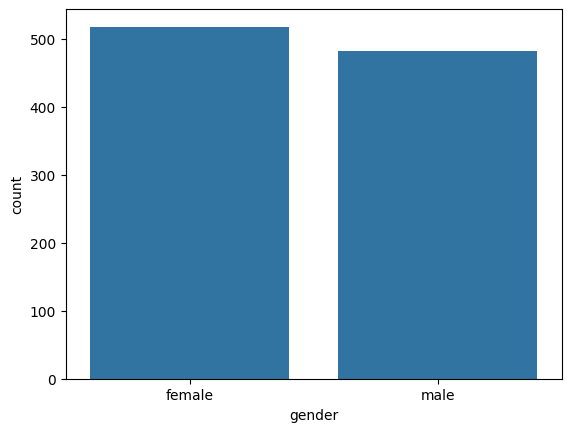

In [15]:
print("Gender Distribution")
print("===============================")

sns.countplot(x='gender', data=df)
plt.show()

Lunch Distribution


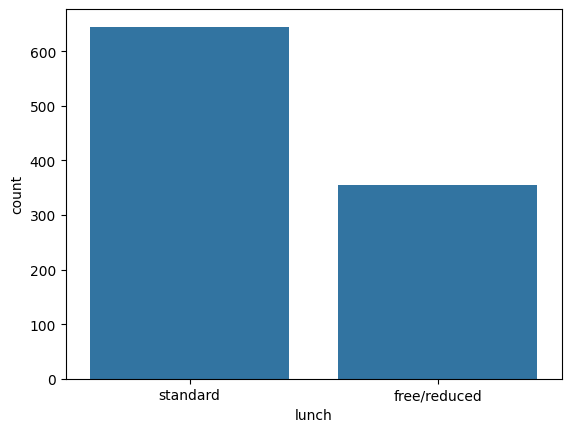

In [16]:
print("Lunch Distribution")
print("===============================")

sns.countplot(x='lunch', data=df)
plt.show()

In [17]:
print("Average Scores")
print("===============================")

df[['math score',
    'reading score',
    'writing score']].mean()

Average Scores


math score       66.089
reading score    69.169
writing score    68.054
dtype: float64

Score Distribution


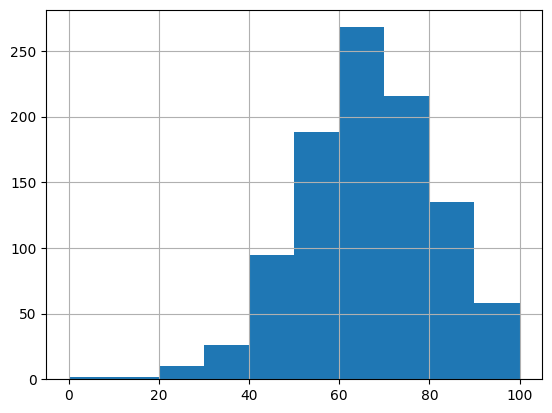

In [18]:
print("Score Distribution")
print("===============================")

df['math score'].hist()
plt.show()

Correlation Heatmap


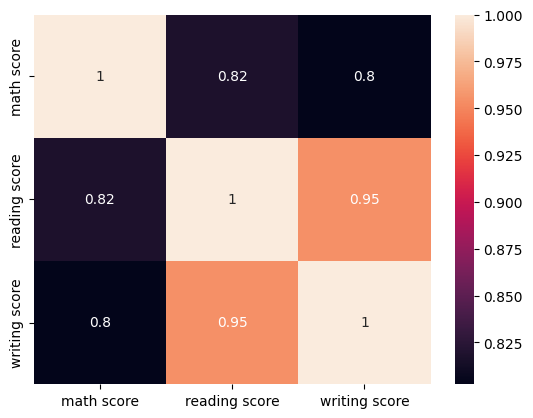

In [23]:
print("Correlation Heatmap")
print("=========================================")

sns.heatmap(
    df[['math score',
        'reading score',
        'writing score']].corr(),
    annot=True
)

plt.show()

# Feature Engineering

In [28]:
print("Average Score")
print("=========================================")

df['average_score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
) / 3

df[['math score', 'reading score', 'writing score', 'average_score']].head()

Average Score


,math score,reading score,writing score,average_score
0,72,72,74,72.666667
1,69,90,88,82.333333
2,90,95,93,92.666667
3,47,57,44,49.333333
4,76,78,75,76.333333


,math score,reading score,writing score,average_score
0,72,72,74,72.666667
1,69,90,88,82.333333
2,90,95,93,92.666667
3,47,57,44,49.333333
4,76,78,75,76.333333


# Label Encoding

In [29]:
le = LabelEncoder()

categorical_cols = df.select_dtypes(
    include='object'
).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,0,1,1,1,1,72,72,74,72.666667
1,0,2,4,1,0,69,90,88,82.333333
2,0,1,3,1,1,90,95,93,92.666667
3,1,0,0,0,1,47,57,44,49.333333
4,1,2,4,1,1,76,78,75,76.333333


# Features and Target

In [33]:
# 1. Features (X) तय करें - इसमें सिर्फ Demographics होंगे, कोई भी score नहीं होगा
X = df.drop(columns=['math score', 'reading score', 'writing score', 'average_score'])

# 2. Target (y) तय करें - जिसे हमें predict करना है
y = df['average_score']

# 3. डेटा को Train और Test में बांटें
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# चेक करने के लिए कि X में कौन से कॉलम्स बचे हैं
print("Features in X:", X.columns.tolist())


Features in X: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [35]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [36]:
print("R2 Score:",
      r2_score(y_test, pred_lr))

R2 Score: 0.1255652122569746


In [37]:
print("MAE:",
      mean_absolute_error(y_test,
                          pred_lr))

MAE: 10.717163335369497


In [38]:
print("RMSE:",
      np.sqrt(
          mean_squared_error(
              y_test,
              pred_lr
          )
      ))

RMSE: 13.691222853433064


# Decision Tree

In [39]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [40]:
print(
    r2_score(
        y_test,
        pred_dt
    )
)

-0.09326723983276541


# Random Forest

In [41]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [42]:
print(
    r2_score(
        y_test,
        pred_rf
    )
)

-0.028607182521283248


# Model Comparison

In [43]:
models = pd.DataFrame({

    'Model':[
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'R2 Score':[

        r2_score(
            y_test,
            pred_lr
        ),

        r2_score(
            y_test,
            pred_dt
        ),

        r2_score(
            y_test,
            pred_rf
        )
    ]
})

models

,Model,R2 Score
0,Linear Regression,0.125565
1,Decision Tree,-0.093267
2,Random Forest,-0.028607


# Feature Importance

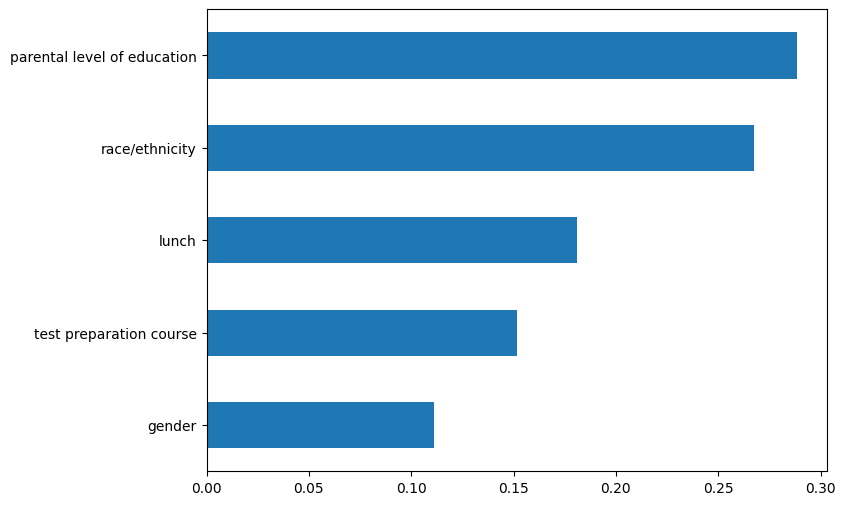

In [44]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,6)
)

plt.show()

# Final Conclusion
1. Reading and Writing scores are highly correlated.
2. Students completing test preparation courses perform better.
3. Random Forest achieved the highest prediction accuracy.
4. Average score can be predicted effectively using demographic and academic features.